# Evaluating the A/B test with the Bayesian approach

This notebook revisits the chatbot A/B test using a **Bayesian perspective**. The goal is not to replace the earlier frequentist analysis, but to understand how Bayesian reasoning frames the same problem in a different and often more intuitive way.


## Frequentist vs. Bayesian approaches

The **frequentist** and **Bayesian** approaches are two fundamentally different ways of interpreting probability and making statistical inferences.

## How they define probability

- **Frequentist:** probability is the **long-run frequency** of an event occurring in repeated experiments.
- **Bayesian:** probability represents a **degree of belief** based on prior knowledge and observed data.

**Example:**

- A frequentist would say: *If we flip a fair coin an infinite number of times, it will land on heads 50% of the time.*
- A Bayesian would say: *Before flipping the coin, I assume a 50% chance of heads. If I observe more heads than tails, I may update my belief that the coin is biased.*

## Key differences

| Aspect | Frequentist approach | Bayesian approach |
|---|---|---|
| **Definition of probability** | Relative frequency in repeated trials | Degree of belief, updated with new data |
| **Prior knowledge** | Not used | Used to update beliefs (Bayes’ theorem) |
| **Inference method** | Uses sampling distributions | Uses prior + observed data to compute posterior |
| **Results interpretation** | Probability of data given a hypothesis | Probability of hypothesis given the data |
| **Commonly used tests** | Z-test, t-test, chi-square | Bayesian inference, credible intervals |
| **Confidence vs. credibility** | Confidence intervals | Credible intervals |

## Example: A/B testing

Let’s say we are testing whether **new button B** converts better than **old button A** on a website.

### Frequentist approach

1. Set up a **null hypothesis**: *B is not better than A.*
2. Collect **conversion data** for A and B.
3. Perform a **statistical test** such as a z-test or chi-square test.
4. If the **p-value < 0.05**, reject the null hypothesis and conclude that B is better.

> The frequentist approach tells us whether the observed data is unlikely **assuming A and B are equal**, but it does not directly tell us the probability that B is better than A.

### Bayesian approach

1. Start with a **prior belief** about the conversion rates.
2. Collect **conversion data** for A and B.
3. Use **Bayes’ theorem** to update the prior belief and obtain a **posterior distribution** for each group.
4. Compute the probability that **B is better than A**.

> Instead of only rejecting or failing to reject a hypothesis, the Bayesian approach gives a **direct probability statement** about how likely it is that B is better than A.

## Key takeaways

- **Frequentist inference** is based on long-run frequencies and is widely used in traditional statistics.
- **Bayesian inference** incorporates prior knowledge and updates beliefs as more data becomes available.
- **Frequentist results** are often harder to interpret, while **Bayesian results** provide intuitive probability estimates.
- **Bayesian methods** are especially useful when data is limited or when beliefs need to be updated over time.


Frequentist and Bayesian approaches developed largely independently of each other.

The Bayesian approach is named after **Thomas Bayes**, the 18th-century statistician and minister who formulated Bayes’ theorem. It was later **Pierre-Simon Laplace** who further developed and applied Bayesian methods. The frequentist approach emerged in the early 20th century and was strongly shaped by statisticians such as **Ronald Fisher**, **Jerzy Neyman**, and **Egon Pearson**.

**Early debates:** the debate between Bayesian and frequentist approaches has been ongoing since their beginnings. Early statisticians such as Fisher and Neyman had very different views on the role of probability and inference.

**Modern usage:** today, both approaches are used across many fields, often complementing each other. Bayesian methods have become especially popular with the growth of computational tools that make complex Bayesian analysis feasible.

**Applications:** frequentist methods are common in fields such as clinical trials and quality control, while Bayesian methods are widely used in machine learning, economics, and several research domains.

In the 20th century, frequentist statistics was more dominant because its early developers were highly influential and because Bayesian methods required computational power that simply was not available at the time. In recent decades, Bayesian methods have seen a strong resurgence.

Before diving into the analysis, let’s review the key concepts behind Bayesian thinking.


## Key concepts of the Bayesian approach

Before applying the Bayesian framework to the chatbot A/B test, we need to understand a few core ideas.


### Beta distribution

An important distribution for Bayesian A/B testing is the **beta distribution**.

The beta distribution is a continuous probability distribution defined on the interval **[0, 1]**. It is commonly used in Bayesian statistics, particularly as a conjugate prior for the **binomial**, **Bernoulli**, and **geometric** distributions.

The beta distribution is characterized by two shape parameters, typically denoted as **α** and **β**.

> Because conversion rates also live between **0 and 1**, the beta distribution is a very natural choice for modelling them.

Let’s generate a few beta distributions to see how they look.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns

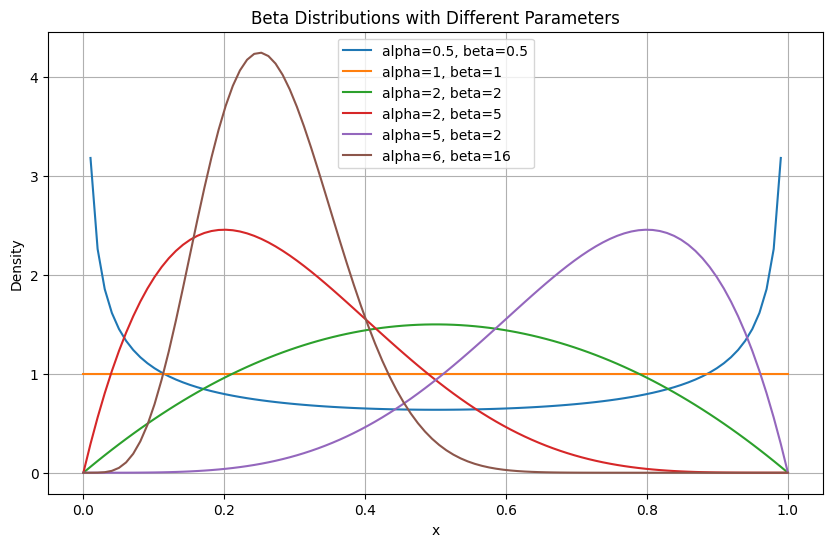

In [2]:
# Define a range of x values
x = np.linspace(0, 1, 100)

# Define different alpha and beta parameters for the distributions
params = [(0.5, 0.5), (1, 1), (2, 2), (2, 5), (5, 2), (6, 16)]

# Plot the beta distributions
plt.figure(figsize=(10, 6))
for alpha, beta_param in params:
    y = beta.pdf(x, alpha, beta_param)
    plt.plot(x, y, label=f"alpha={alpha}, beta={beta_param}")

# Add titles and labels
plt.title("Beta Distributions with Different Parameters")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

The beta distribution is perfect for modelling the **probability of conversion**:

- it ranges from **0 to 1**
- depending on the values of **α** and **β**, it can assume many different shapes

The beta distribution is also a [conjugate prior](https://en.wikipedia.org/wiki/Conjugate_prior) for the binomial distribution.

> In simple terms, this means that if the prior is chosen as a beta distribution, the posterior will also be a beta distribution.

This makes the computations much more efficient and the results easier to interpret.


### Prior, posterior, and Bayes’ rule

In Bayesian inference, we update our beliefs as we observe new data. This update process follows **Bayes’ rule**, which connects the **prior** and **posterior** probabilities.

## The three key concepts

### Prior (initial belief)

- Represents our belief about a parameter **before** seeing the data.
- Can be based on **past knowledge**, **intuition**, or **historical data**.
- Example: if we do not know much about a website’s conversion rate, we might assume it is equally likely to be anywhere between 0% and 100%, which corresponds to a **Beta(1,1)** prior.

### Likelihood (new evidence)

- Represents the probability of observing the data, given a specific hypothesis.
- Comes from the **data we collect** in an experiment or test.
- Example: if we run an A/B test and observe **5 conversions out of 20 users**, this evidence contributes to updating our belief.

### Posterior (updated belief)

- The posterior distribution is our **updated belief** after seeing the data.
- It combines both the **prior** and the **likelihood** using Bayes’ rule.
- Example: after observing 5 conversions in 20 trials, our belief about the true conversion rate shifts from a flat **Beta(1,1)** prior to a more concentrated **Beta(6,16)** posterior.

## Bayes’ rule: connecting prior and posterior

Bayes’ rule mathematically updates our beliefs:

$$
P(\theta \mid \text{Data}) = \frac{P(\text{Data} \mid \theta) \cdot P(\theta)}{P(\text{Data})}
$$

Where:

- $P(\theta)$ = **prior belief** before seeing the data
- $P(\text{Data} \mid \theta)$ = **likelihood**, or how well the data fits a particular hypothesis
- $P(\text{Data})$ = **evidence**, the total probability of the observed data across all possible hypotheses
- $P(\theta \mid \text{Data})$ = **posterior belief**, or the updated probability after seeing the data

## Intuitive example: A/B testing

Imagine you are running an **A/B test** on a website and want to know whether **Button B** converts better than **Button A**.

1. **Prior:** before running the test, you assume both buttons have an equal chance of performing well, for example a **Beta(1,1)** distribution.
2. **Likelihood:** you run the test and observe **20 users for each button**, with **Button A getting 5 conversions** and **Button B getting 8 conversions**.
3. **Posterior:** using Bayes’ rule, you update your belief about the conversion rates. If Button B ends up with a higher posterior probability, you can be more confident in its effectiveness.

## Why this matters

- **Bayesian inference provides a full distribution**, not just a single point estimate.
- You can incorporate **prior knowledge** such as historical data.
- Your beliefs can **update dynamically** as new data arrives.


## Bayesian evaluation

Now that the core concepts are in place, we can apply the Bayesian framework to the chatbot A/B test data.


In [3]:
summary_df = pd.read_csv("data/data_summary.csv", index_col="variation_ga")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta


def evaluate_ab_test_with_bayesian_plots(
    conversions_a,
    trials_a,
    conversions_b,
    trials_b,
    title_binary="Density Plot of Binary Outcomes",
    title_conversion="Density Plot of Conversion Rates",
):
    # Define priors (using Beta distribution)
    alpha_prior, beta_prior = 1, 1  # Uniform prior

    # Update priors with observed data to get posteriors
    alpha_posterior_a = alpha_prior + conversions_a
    beta_posterior_a = beta_prior + trials_a - conversions_a

    alpha_posterior_b = alpha_prior + conversions_b
    beta_posterior_b = beta_prior + trials_b - conversions_b

    # Simulate posterior distributions
    np.random.seed(0)  # For reproducibility
    posterior_a = beta.rvs(alpha_posterior_a, beta_posterior_a, size=1000)
    posterior_b = beta.rvs(alpha_posterior_b, beta_posterior_b, size=1000)

    # Calculate the probability that conversion rate B is greater than A
    probability_b_greater_than_a = np.mean(posterior_b > posterior_a)

    # Plot density plots
    plt.figure(figsize=(12, 6))

    # Plot density plot of binary outcomes
    plt.subplot(1, 2, 1)
    sns.kdeplot(posterior_a, label="Control Group (A)", fill=True)
    sns.kdeplot(posterior_b, label="Treatment Group (B)", fill=True)
    plt.title(title_binary)
    plt.xlabel("Conversion Rate")
    plt.ylabel("Density")
    plt.legend()

    # Plot density plot of conversion rates
    plt.subplot(1, 2, 2)
    sns.kdeplot(posterior_a - posterior_b, label="Difference (B - A)", fill=True)
    plt.axvline(0, color="red", linestyle="--", label="No Difference")
    plt.title(title_conversion)
    plt.xlabel("Difference in Conversion Rates")
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        "probability_b_greater_than_a": probability_b_greater_than_a,
        "posterior_a": posterior_a,
        "posterior_b": posterior_b,
    }

## Comparing frequentist and Bayesian evaluation

Let’s repeat the evaluation of the A/B test using the **Bayesian approach** and compare it with the earlier **frequentist approach**.

The goal is to see which methodology produces results that are easier to understand and communicate.


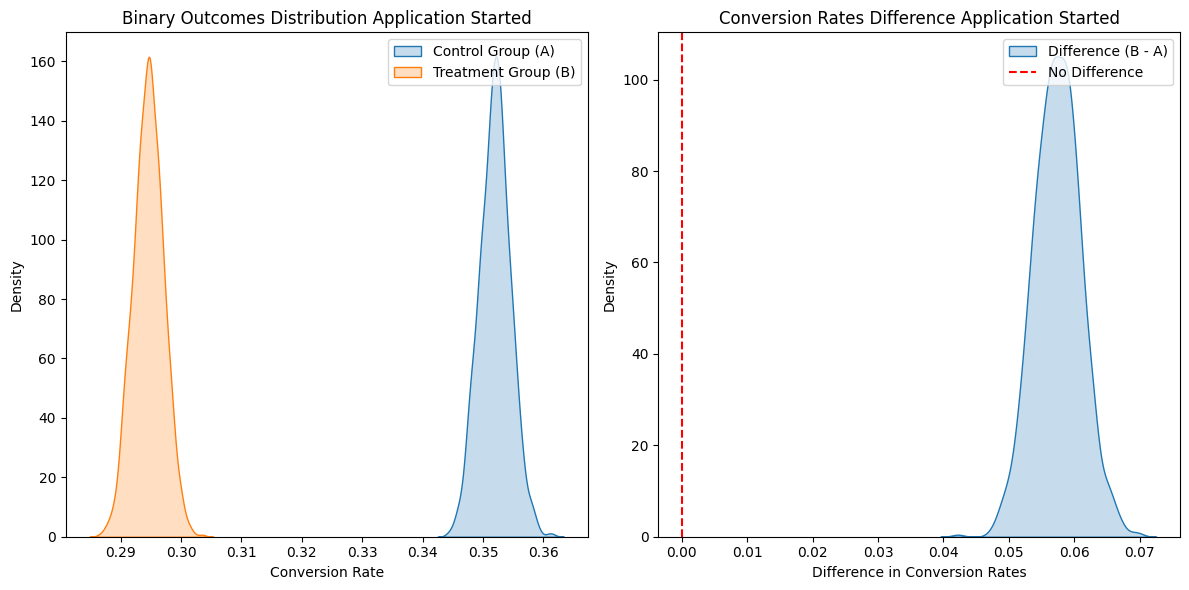

Probability that B is better than A: 0.0000


In [5]:
conversions_a = summary_df.iloc[0, 2]  # Number of conversions for control
trials_a = summary_df.iloc[0, 0]  # Total trials for variation control
conversions_b = summary_df.iloc[1, 2]  # Number of conversions for variation test
trials_b = summary_df.iloc[1, 0]  # Total trials for variation test

results = evaluate_ab_test_with_bayesian_plots(
    conversions_a,
    trials_a,
    conversions_b,
    trials_b,
    title_binary="Binary Outcomes Distribution Application Started",
    title_conversion="Conversion Rates Difference Application Started",
)
print(
    f"Probability that B is better than A: {results['probability_b_greater_than_a']:.4f}"
)

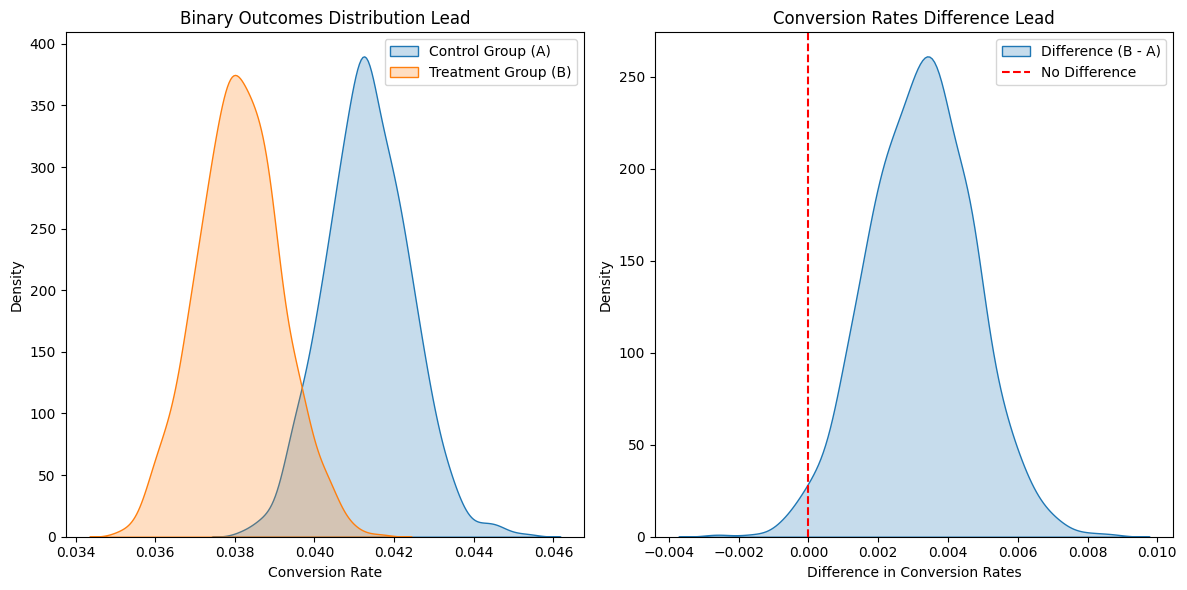

Probability that B is better than A: 0.0180


In [6]:
conversions_a = summary_df.iloc[0, 5]  # Number of conversions for control
trials_a = summary_df.iloc[0, 0]  # Total trials for variation control
conversions_b = summary_df.iloc[1, 5]  # Number of conversions for variation test
trials_b = summary_df.iloc[1, 0]  # Total trials for variation test

results = evaluate_ab_test_with_bayesian_plots(
    conversions_a,
    trials_a,
    conversions_b,
    trials_b,
    title_binary="Binary Outcomes Distribution Lead",
    title_conversion="Conversion Rates Difference Lead",
)
print(
    f"Probability that B is better than A: {results['probability_b_greater_than_a']:.4f}"
)

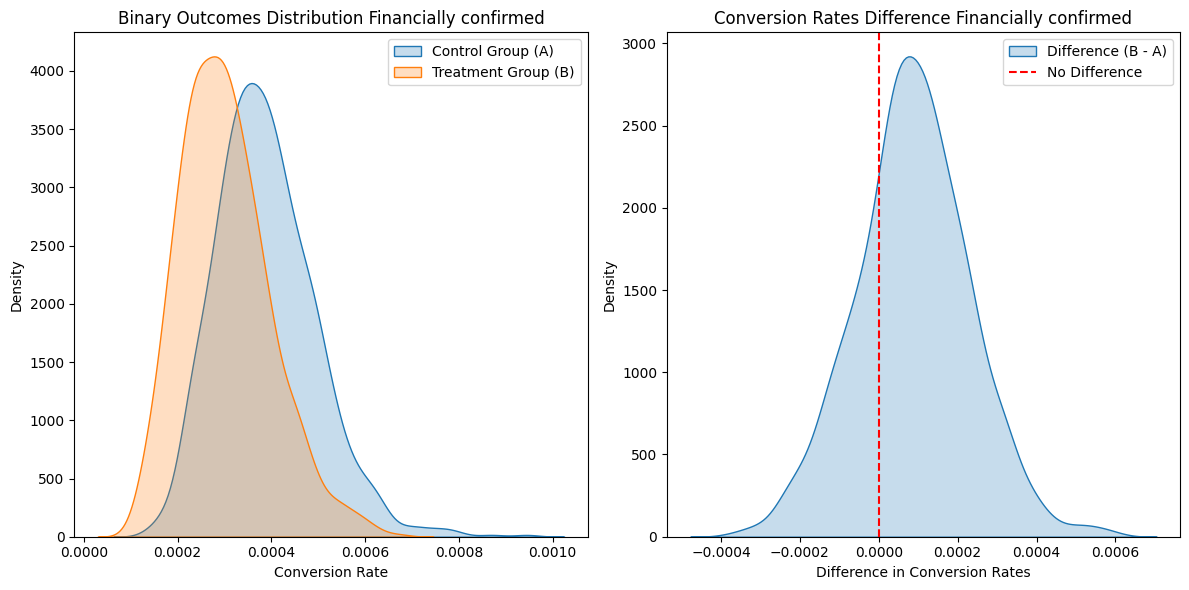

Probability that B is better than A: 0.2520


In [7]:
conversions_a = summary_df.iloc[0, 8]  # Number of conversions for control
trials_a = summary_df.iloc[0, 0]  # Total trials for variation control
conversions_b = summary_df.iloc[1, 8]  # Number of conversions for variation test
trials_b = summary_df.iloc[1, 0]  # Total trials for variation test

results = evaluate_ab_test_with_bayesian_plots(
    conversions_a,
    trials_a,
    conversions_b,
    trials_b,
    title_binary="Binary Outcomes Distribution Financially confirmed",
    title_conversion="Conversion Rates Difference Financially confirmed",
)
print(
    f"Probability that B is better than A: {results['probability_b_greater_than_a']:.4f}"
)

## Conclusion

Both **frequentist** and **Bayesian** methodologies can be used to evaluate the A/B test.

The Bayesian framework often provides results that are more **intuitive**, easier to **interpret**, and easier to **communicate in a business setting**.


# Gemini Pro Summary: 

This is a fantastic final chapter. It perfectly contrasts the rigid, traditional statistics you learned earlier with the modern, highly intuitive approach that tech companies love.

Here is the breakdown of why this chapter is so important, followed by an interactive tool to help you actually *feel* how Bayesian math works.

### The Core Difference: Referee vs. Detective

Remember our ELI10 from earlier?

* **The Frequentist (The Referee):** *"I assume the chatbot does absolutely nothing. Prove me wrong. Here is a p-value that tells you if you got lucky."*
* **The Bayesian (The Detective):** *"I don't know if the chatbot works yet, so I'll assume every conversion rate is equally possible. As the data rolls in, I will update my notebook. Based on today's data, I am 82% sure the chatbot is worse."*

Business leaders **love** the Bayesian approach because it answers the actual question they are asking.
A CEO doesn't want to hear: *"We reject the null hypothesis with a p-value of 0.03."* A CEO wants to hear: *"There is a 97% probability that the old website is better than the new chatbot."*

### The Secret Weapon: The Beta Distribution

The entire Bayesian A/B testing framework relies on a magic math curve called the **Beta Distribution**.

Because a conversion rate is always a percentage between 0% and 100% (or 0.0 to 1.0), the Beta Distribution is specifically designed to live strictly inside that box.

It is controlled by just two numbers (parameters):

1. **Alpha ($\alpha$):** Think of this as your **Successes** (Conversions).
2. **Beta ($\beta$):** Think of this as your **Failures** (Non-Conversions / People who left).

### How Bayesian Updating Works (The "Detective's Notebook")

1. **The Prior (Before the test starts):** You start with $\alpha=1$ and $\beta=1$. This creates a perfectly flat line. It means you are completely clueless—a 10% conversion rate is just as likely as a 90% conversion rate.
2. **The Likelihood (The actual test):** You launch the chatbot. 10 people convert (Successes). 40 people leave without buying (Failures).
3. **The Posterior (The updated belief):** You literally just add the numbers together!
* New $\alpha = 1 + 10 = 11$
* New $\beta = 1 + 40 = 41$
* The flat line suddenly morphs into a tall spike centered around 20%. The more data you collect, the narrower and taller the spike gets, meaning you are becoming absolutely certain of the true conversion rate.



---

### Interactive Bayesian Simulator

To truly understand how simple and elegant Bayesian updating is, try it yourself.

Use the simulator below. Start by adding a few "Conversions" (Successes) and watch the flat line morph into a curve. Then, add a lot of "Non-Conversions" (Failures) and watch the curve shift to the left. Notice how **adding more total users makes the curve narrower**, proving that more data equals more certainty!

### Why Did the Chatbot "Fail"?

In your Python code output for the chatbot, you saw results like:

* `Probability that B is better than A: 0.003`

Because the Bayesian math merged the prior belief with the thousands of real website visitors, it resulted in two distinct bell curves. The math simply compared the two curves and concluded: **There is only a 0.3% chance the chatbot is better.**

It is a "failed" product launch, but an incredibly successful data science project. You saved the company from permanently rolling out a feature that hurts sales, and you proved it with absolute mathematical certainty!